In [5]:
import torch.nn as nn
import torch.functional as F
from torch.utils.data import DataLoader, Dataset
import pandas as pd
from sklearn.preprocessing import StandardScaler
import pickle, copy, os, torch




In [8]:
class LSTMblock(nn.Module): #takes in (B, 14), spits out (B, 128)
    def __init__(self):
        super().__init__()

        #Forget Gate
        self.Wf = nn.Parameter(torch.randn(128, 14), requires_grad=True)
        self.Uf = nn.Parameter(torch.randn(128, 128), requires_grad=True)
        self.bf = nn.Parameter(torch.zeros(128), requires_grad=True)

        #Input Gate
        self.Wi = nn.Parameter(torch.randn(128, 14), requires_grad=True)
        self.Ui = nn.Parameter(torch.randn(128, 128), requires_grad=True)
        self.bi = nn.Parameter(torch.zeros(128), requires_grad=True)

        #Candidate Cell
        self.Wc = nn.Parameter(torch.randn(128, 14), requires_grad=True)
        self.Uc = nn.Parameter(torch.randn(128, 128), requires_grad=True)
        self.bc = nn.Parameter(torch.zeros(128), requires_grad=True)

        #Output Gate
        self.Wo = nn.Parameter(torch.randn(128, 14), requires_grad=True)
        self.Uo = nn.Parameter(torch.randn(128, 128), requires_grad=True)
        self.bo = nn.Parameter(torch.zeros(128), requires_grad=True)

        #Input weights
        nn.init.xavier_uniform_(self.Wf)
        nn.init.xavier_uniform_(self.Wi)
        nn.init.xavier_uniform_(self.Wc)
        nn.init.xavier_uniform_(self.Wo)
        
        #Recurrent weights
        nn.init.orthogonal_(self.Uf)
        nn.init.orthogonal_(self.Ui)
        nn.init.orthogonal_(self.Uc)
        nn.init.orthogonal_(self.Uo)

        self.sigm = nn.Sigmoid()
        self.tanh = nn.Tanh()

    def forward(self, inputs, m):

        ltm, stm = m

        #Forget Gate
        f = self.sigm(inputs @ self.Wf.T + stm @ self.Uf.T + self.bf)

        #Input Gate
        i = self.sigm(inputs @ self.Wi.T + stm @ self.Ui.T + self.bi)

        #Candidate Cell
        g = self.tanh(inputs @ self.Wc.T + stm @ self.Uc.T + self.bc)

        #Output Gate
        o = self.sigm(inputs @ self.Wo.T + stm @ self.Uo.T + self.bo)

        #Update states
        ltm = f * ltm + i * g
        stm = o * self.tanh(ltm)

        return (ltm, stm)

In [ ]:
class VanillaLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.LSTM = LSTMblock()
        self.Head = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 144)
        )

    def forward(self, inputs): #shape (B, 432, 14)
        batch, time_period, h_lenght = inputs.shape

        ltm = torch.zeros(batch, 128, device=inputs.device)
        stm = torch.zeros(batch, 128, device=inputs.device)


        for t in range(time_period):
            in_vals = inputs[:, t, :]
            ltm, stm = self.LSTM(in_vals, (ltm, stm))

            
        output = self.Head(stm)
        
        return output

In [10]:
class ClimateLog(Dataset):
    def __init__(self, root, train=True):
        super().__init__()
        self.root = root
        self.scaler = StandardScaler()

        df = pd.read_csv(self.root).iloc[:420336].copy()
        del df['Date Time']

        split_idx = int(0.9 * len(df))

        train_df = df.iloc[:split_idx].copy()
        val_df = df.iloc[split_idx:].copy()

        self.train_dataset = torch.tensor(
            self.scaler.fit_transform(train_df.values),
            dtype=torch.float32
        )

        self.val_dataset = torch.tensor(
            self.scaler.transform(val_df.values),
            dtype=torch.float32
        )

        self.stride = 6
        self.train = train

    def __len__(self):
        dataset = self.train_dataset if self.train else self.val_dataset
        return (len(dataset) - 432 - 72 + 1) // self.stride

    def __getitem__(self, index):
        index *= self.stride

        dataset = self.train_dataset if self.train else self.val_dataset

        inputs = dataset[index:index+432, :]
        labels = dataset[index+432:index+432+72, 2]

        return inputs, labels

In [11]:
train_dataset = ClimateLog("/kaggle/input/datasets/quphine/jena-climate/jena_climate_2009_2016.csv", train=True)
val_dataset = ClimateLog("/kaggle/input/datasets/quphine/jena-climate/jena_climate_2009_2016.csv", train=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    pin_memory=True
)

In [12]:
def train_model(
    model, optimizer, criterion, train_loader, val_loader,
    scheduler, loss_dict, acc_dict, n_epochs, device,
    checkpoint_path="latest_checkpoint.pth"
):
    start_epoch = 0
    best_loss    = 1000.0

    if torch.cuda.device_count() > 1 and not isinstance(model, nn.DataParallel):
        print(f"Using {torch.cuda.device_count()} GPUs")
        model = nn.DataParallel(model)
    model = model.to(device)

    if os.path.exists(checkpoint_path):
        print("Checkpoint found. Resuming training...")
        ckpt = torch.load(checkpoint_path, map_location=device)
        (model.module if isinstance(model, nn.DataParallel) else model).load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        start_epoch = ckpt["epoch"] + 1
        best_loss    = ckpt["best_loss"]
        loss_dict.update(ckpt["loss_dict"])
        acc_dict.update(ckpt["acc_dict"])
        print(f"Resumed from Epoch {start_epoch}")

    best_wts = copy.deepcopy(
        (model.module if isinstance(model, nn.DataParallel) else model).state_dict()
    )

    for epoch in range(start_epoch, n_epochs):
        print(f"\nEpoch [{epoch+1}/{n_epochs}]  lr={scheduler.get_last_lr()[0]:.6f}")

        model.train()
        train_loss = 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss    += loss.item() * images.size(0)

            if (i + 1) % 50 == 0 or (i + 1) == len(train_loader):
                print(f"  Step [{i+1}/{len(train_loader)}] Loss: {loss.item():.4f}")

        epoch_train_loss = train_loss    / len(train_loader.dataset)
        loss_dict["train"].append(epoch_train_loss)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs    = model(images)
                loss       = criterion(outputs, labels)
                val_loss  += loss.item() * images.size(0)

        epoch_val_loss = val_loss    / len(val_loader.dataset)
        loss_dict["val"].append(epoch_val_loss)

        scheduler.step(epoch_val_loss)

        if epoch_val_loss < best_loss:
            best_loss = epoch_val_loss
            best_wts = copy.deepcopy(
                (model.module if isinstance(model, nn.DataParallel) else model).state_dict()
            )

        print("-" * 60)
        print(f"Train Loss: {epoch_train_loss:.4f} ")
        print(f"Val   Loss: {epoch_val_loss:.4f} (best: {best_loss:.4f})")
        print("-" * 60)

        raw_state = (model.module if isinstance(model, nn.DataParallel) else model).state_dict()
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     raw_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_loss":             best_loss,
            "loss_dict":            loss_dict,
            "acc_dict":             acc_dict,
        }, checkpoint_path)

    torch.save(best_wts, "model_wts.pth")
    with open("acc_loss.bin", "wb") as f:
        pickle.dump([loss_dict, acc_dict], f)

    (model.module if isinstance(model, nn.DataParallel) else model).load_state_dict(best_wts)
    print(f"\nTraining Complete! Best Val loss: {best_loss:.4f}")
    return model

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
num_epochs = 50

criterion = nn.MSELoss()
model = VanillaLSTM()
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)


KAGGLE_INPUT_CHECKPOINT = "/kaggle/input/models/quphine/v2-cifar/transformers/default/1/latest_checkpoint.pth"
OUTPUT_CHECKPOINT_PATH  = "/kaggle/working/latest_checkpoint.pth"

import shutil
if os.path.exists(KAGGLE_INPUT_CHECKPOINT) and not os.path.exists(OUTPUT_CHECKPOINT_PATH):
    print("Linking Kaggle input checkpoint...")
    shutil.copy(KAGGLE_INPUT_CHECKPOINT, OUTPUT_CHECKPOINT_PATH)

loss_dict = {'train': [], 'val': []}
acc_dict  = {'train': [], 'val': []}

train_model(
    model=model,
    device=device,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    scheduler=scheduler,
    loss_dict=loss_dict,
    acc_dict=acc_dict,
    n_epochs=num_epochs,
    checkpoint_path=OUTPUT_CHECKPOINT_PATH,
)

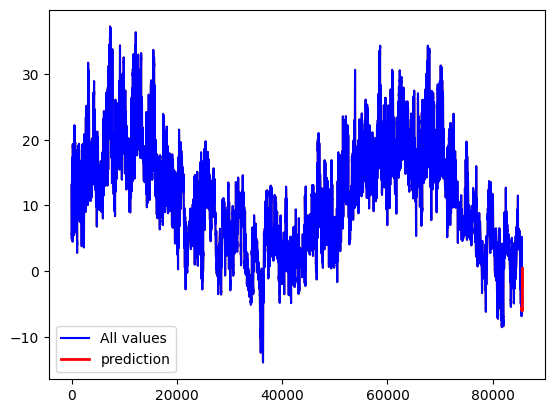

In [13]:
#inference
import matplotlib
device = 'cpu'
model = VanillaLSTM()
model.to(device)
state_dict = torch.load('/kaggle/input/models/quphine/vanillalstm/pytorch/default/1/model_wts.pth', map_location=torch.device('cpu'))
model.load_state_dict(state_dict)

root = '/kaggle/input/datasets/quphine/jena-climate/jena_climate_2009_2016.csv'
scaler_ = ClimateLog('/kaggle/input/datasets/quphine/jena-climate/jena_climate_2009_2016.csv')


scaler = scaler_.scaler
df = pd.read_csv(root).iloc[420119:].copy()
del df['Date Time']

df_o = pd.read_csv(root).iloc[335000:].copy()
del df_o['Date Time']

temp_mean = scaler.mean_[1]
temp_std  = scaler.scale_[1]

dataset_o = torch.tensor(
    scaler.transform(df_o.values),
    dtype=torch.float32
).to(device)

dataset = torch.tensor(
    scaler.transform(df.values),
    dtype=torch.float32
).to(device)

model.eval()
with torch.no_grad():
    output = model(dataset.unsqueeze(0))

dataset_temp_c_o = temp_std * dataset_o[:, 1] + temp_mean
pred_temp_c    = temp_std * output.squeeze(0) + temp_mean

k = torch.cat([dataset_temp_c_o, pred_temp_c], dim=0)

matplotlib.pyplot.plot([])
matplotlib.pyplot.plot([i for i in range(len(k))], k)

import matplotlib.pyplot as plt


plt.plot(range(len(k)), k, label="All values", color="blue")


plt.plot(range(len(k)-72, len(k)), k[-72:], 
         label="prediction", color="red", linewidth=2)


plt.legend()
plt.show()


In [ ]:
import torch
from sklearn.metrics import r2_score
device = 'cuda'
def evaluate_r2(model, val_loader, device):
    model.to(device)
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():

        for inputs, targets in val_loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            predictions = model(inputs)

            all_predictions.append(predictions.cpu())
            all_targets.append(targets.cpu())

    all_predictions = torch.cat(all_predictions, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    all_predictions = all_predictions.reshape(-1).numpy()
    all_targets = all_targets.reshape(-1).numpy()

    r2 = r2_score(all_targets, all_predictions)

    print(f"Validation R² Score : {r2:.4f}")

    return r2

evaluate_r2(model, val_loader, device)

Validation R² Score : 0.9465


0.9465436339378357

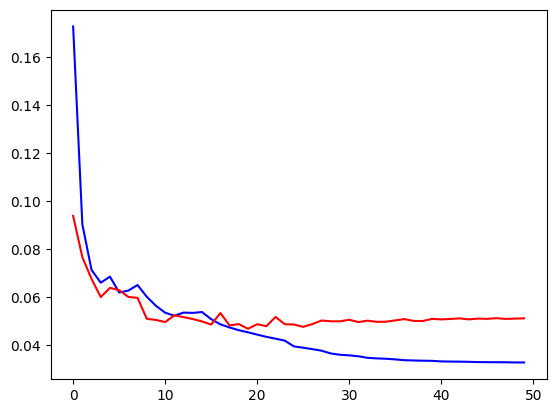

In [ ]:
#loss analysis

import pickle

with open('acc_loss.bin', 'rb') as file:
    out = pickle.load(file)

import matplotlib.pyplot as plt

train_loss = out[0]['train']
val_loss = out[0]['val']

plt.plot(train_loss, color='b')
plt.plot(val_loss, color='r')